[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Forward Propagation, Backward Propagation, and Computational Graphs

So far, we have trained our models with minibatch stochastic gradient descent.
However, when we implemented the algorithm, we only worried about the calculations involved
in *forward propagation* through the model.
When it came time to calculate the gradients,
we simply invoked the PyTorch's built in ability to compute gradients via the `backward()` function, which implements the **backpropagation algorithm**.

The automatic calculation of gradients profoundly simplifies the implementation of deep learning algorithms.
Before automatic differentiation, even small changes to complicated models required
recalculating complicated derivatives by hand.
Academic papers had to allocate pages to deriving update rules.
While we will continue to rely on automatic differentiation so we can focus on the interesting parts,
you ought to know how these gradients are calculated under the hood if you want to go beyond a shallow understanding of deep learning.

## Forward Propagation

*Forward propagation* (or *forward pass*) refers to the calculation and storage
of network output and intermediate variables.
Below we will introduce the concept of a "computational graph" to represent the forward propagation of a neural network.  To introduce the concept we will first define a simple network with a single hidden layer.

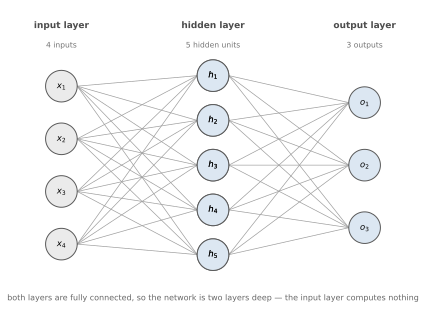

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import numpy as np
import matplotlib.pyplot as plt

def _fc_network(ax, in_labels, out_labels, x_in=0.0, x_out=2.6, r=0.30,
                dy=0.95, dy_out=None, in_fill='0.92', out_fill='#dce7f2',
                edge_color='0.62', edge_lw=0.7):
    """A fully connected layer: every input circle joined to every output."""
    from matplotlib.patches import Circle

    dy_out = dy if dy_out is None else dy_out
    n_in, n_out = len(in_labels), len(out_labels)
    y_in = [(n_in - 1) / 2 * dy - i * dy for i in range(n_in)]
    y_out = [(n_out - 1) / 2 * dy_out - i * dy_out for i in range(n_out)]

    for yi in y_in:
        for yo in y_out:
            ax.plot([x_in + r, x_out - r], [yi, yo], color=edge_color,
                    linewidth=edge_lw, zorder=1)
    for y, label in zip(y_in, in_labels):
        ax.add_patch(Circle((x_in, y), r, facecolor=in_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_in, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    for y, label in zip(y_out, out_labels):
        ax.add_patch(Circle((x_out, y), r, facecolor=out_fill, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
        ax.text(x_out, y, label, ha='center', va='center', fontsize=8.5, zorder=4)
    return y_in, y_out

def mlp_figure():
    """A one-hidden-layer MLP: 4 inputs, 5 hidden units, 3 outputs."""
    grey, blue = '0.92', '#dce7f2'
    r = 0.24
    dy_in, dy_hid, dy_out = 0.80, 0.68, 0.95
    x_in, x_hid, x_out = 0.0, 2.3, 4.6

    hidden = ['$h_1$', '$h_2$', '$h_3$', '$h_4$', '$h_5$']
    fig, ax = plt.subplots(figsize=(6.10, 4.35))

    y_in, y_hid = _fc_network(ax, ['$x_1$', '$x_2$', '$x_3$', '$x_4$'], hidden,
                              x_in, x_hid, r, dy_in, dy_out=dy_hid,
                              in_fill=grey, out_fill=blue)
    _, y_out = _fc_network(ax, hidden, ['$o_1$', '$o_2$', '$o_3$'],
                           x_hid, x_out, r, dy_hid, dy_out=dy_out,
                           in_fill=blue, out_fill=blue)

    top = max(max(y_in), max(y_hid), max(y_out)) + r
    for x, name, sub in [(x_in, 'input layer', '4 inputs'),
                         (x_hid, 'hidden layer', '5 hidden units'),
                         (x_out, 'output layer', '3 outputs')]:
        ax.text(x, top + 0.52, name, ha='center', va='center', fontsize=9,
                fontweight='bold', color='0.3')
        ax.text(x, top + 0.22, sub, ha='center', va='center', fontsize=7.6,
                color='0.45')

    bottom = min(min(y_in), min(y_hid), min(y_out)) - r
    ax.text((x_in + x_out) / 2, bottom - 0.42,
            'both layers are fully connected, so the network is two layers deep '
            '— the input layer computes nothing',
            ha='center', va='center', fontsize=8, color='0.4')

    ax.set_xlim(x_in - 0.75, x_out + 0.75)
    ax.set_ylim(bottom - 0.75, top + 0.80)
    ax.set_aspect('equal')
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

mlp_figure()

For simplicity, let's assume that the input example is $\mathbf{x}\in \mathbb{R}^d$
and that our hidden layer does not include a bias term.
Here the intermediate variable is:

$$\mathbf{z}= \mathbf{W}^{(1)} \mathbf{x},$$

where $\mathbf{W}^{(1)} \in \mathbb{R}^{h \times d}$ is the weight matrix of the hidden layer.
After running the intermediate variable $\mathbf{z}\in \mathbb{R}^h$ through the
activation function $\sigma$ we obtain our hidden activation vector of length $h$:

$$\mathbf{h}= \sigma (\mathbf{z}).$$

Assuming that the parameters of the output layer are a weight matrix
$\mathbf{W}^{(2)} \in \mathbb{R}^{q \times h}$,
we obtain the output layer as a vector of length $q$:

$$\mathbf{o}= \mathbf{W}^{(2)} \mathbf{h}.$$

Assuming that the loss function is $l$
and the example label is $y$,
we can then calculate the loss term
for a single data example as

$$L = l(\mathbf{o}, y).$$

We will add to this an $\ell_2$ regularization term with hyperparameter $\lambda$,
defined by:

$$s = \frac{\lambda}{2} \left(\|\mathbf{W}^{(1)}\|_\textrm{F}^2 + \|\mathbf{W}^{(2)}\|_\textrm{F}^2\right),$$

where the Frobenius norm of the matrix
is simply the $\ell_2$ norm applied
after flattening the matrix into a vector.
Finally, the model's regularized loss
on a given data example is:

$$J = L + s.$$

We refer to $J$ as the *objective function* in the following discussion.

## Representing networks with computational graphs

Plotting *computational graphs* helps us visualize
the dependencies of operators
and variables within the calculation.
Below we draw the graph for the simple network
described above,
where squares denote inputs and parameters, and circles denote operations.
Each circle is labeled with the variable it computes, and the edge into it shows the formula.
The lower-left corner signifies the input
and the upper-right corner is the output.
You'll notice that this graph can be described as a directed acyclic graph (DAG).

### Drawing computational graphs

Rather than rely on external images, let's build a small helper so we can draw
computational graphs directly in the notebook. Squares hold inputs and parameters;
circles are operations, labeled with the variable they compute. We'll reuse this to visualize both the forward
values and the backward gradients.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch

# palette shared by every computational graph in this notebook
DATA = '0.92'          # a value we are given
PARAM = '#f0e9e4'      # a parameter we want gradients for
OP = '#dce7f2'         # an operation
OBJ = '#e6dcea'        # the objective at the end of the graph
GRAY, RED, BLUE = '0.55', '#c1440e', '#2c6d9e'


def draw_node(ax, xy, text, shape='circle', color=OP, r=0.42):
    """One graph node: a square for an input or parameter, a circle for an operation."""
    x, y = xy
    if shape == 'circle':
        ax.add_patch(Circle((x, y), r, facecolor=color, edgecolor='0.35',
                            linewidth=1.0, zorder=3))
    else:
        # drawn symmetrically about (x, y) so the label sits at its centre
        bw, bh = r, 0.55 * r
        ax.add_patch(FancyBboxPatch((x - bw, y - bh), 2 * bw, 2 * bh,
                                    boxstyle='round,pad=0.02,rounding_size=0.06',
                                    facecolor=color, edgecolor='0.35',
                                    linewidth=1.0, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=9, zorder=4)


def draw_edge(ax, a, b, label=None, r=0.42, color=GRAY, label_color='0.3',
              curve=0.0, dashed=False, label_off=0.16, label_dx=0.0,
              fontsize=8):
    """A directed edge a -> b, trimmed so the arrow meets the node borders."""
    a, b = np.array(a, float), np.array(b, float)
    u = (b - a) / np.linalg.norm(b - a)
    a2, b2 = a + u * r, b - u * r
    ax.add_patch(FancyArrowPatch(a2, b2, arrowstyle='-|>', mutation_scale=10,
                                 color=color, zorder=2, linewidth=1.0,
                                 connectionstyle=f'arc3,rad={curve}',
                                 linestyle='--' if dashed else '-'))
    if label:
        m = (a2 + b2) / 2
        perp = np.array([-u[1], u[0]])
        p = (m + perp * (curve * np.linalg.norm(b - a) * 0.5)
             + np.array([label_dx, label_off]))
        ax.text(p[0], p[1], label, ha='center', va='bottom', fontsize=fontsize,
                color=label_color, zorder=5,
                bbox=dict(boxstyle='round,pad=0.10', facecolor='white',
                          edgecolor='none', alpha=0.9))


def new_graph_axes(figsize=(8, 3)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.set_aspect('equal')
    return fig, ax


def graph_title(ax, text, pad=6):
    ax.set_title(text, fontsize=10, color='0.3', pad=pad)


# the scalar graph used by the next two figures, laid out once
SCALAR_POS = {'w': (0, 3.4), 'x': (0, 2.0), 'b': (0, 0.8), 'y': (0, -0.4),
              'p': (2.4, 2.7), 'q': (4.6, 1.8), 'r': (6.8, 0.8),
              'f': (9.0, 0.8)}
SCALAR_STYLE = {'w': ('box', PARAM), 'x': ('box', DATA),
                'b': ('box', PARAM), 'y': ('box', DATA),
                'p': ('circle', OP), 'q': ('circle', OP),
                'r': ('circle', OP), 'f': ('circle', OBJ)}


def draw_scalar_nodes(ax):
    """The eight nodes of the scalar graph.

    A square holds an input or parameter; a circle is an operation, labeled
    with the variable it computes (the edge into it shows the formula).
    """
    for n, (shape, color) in SCALAR_STYLE.items():
        draw_node(ax, SCALAR_POS[n], n, shape, color)

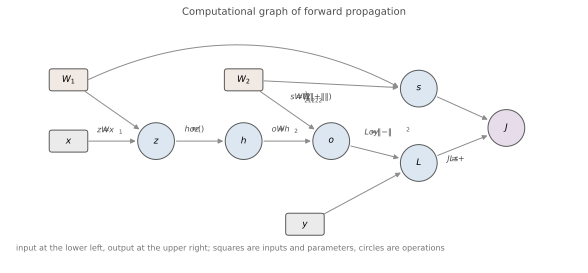

In [3]:
def forward_graph_figure():
    """The forward pass as a DAG: squares are inputs/parameters, circles operations."""
    fig, ax = new_graph_axes(figsize=(11.0, 3.9))

    pos = {'x':  (0.0, 1.4), 'W1': (0.0, 2.8),
           'z':  (2.0, 1.4), 'h':  (4.0, 1.4), 'W2': (4.0, 2.8),
           'o':  (6.0, 1.4), 'y':  (5.4, -0.5),
           'L':  (8.0, 0.9), 's':  (8.0, 2.6),
           'J':  (10.0, 1.7)}
    styles = {'x': ('box', DATA), 'y': ('box', DATA),
              'W1': ('box', PARAM), 'W2': ('box', PARAM),
              'z': ('circle', OP), 'h': ('circle', OP), 'o': ('circle', OP),
              'L': ('circle', OP), 's': ('circle', OP), 'J': ('circle', OBJ)}
    labels = {'x': '$x$', 'y': '$y$', 'W1': '$W_1$', 'W2': '$W_2$', 'z': '$z$',
              'h': '$h$', 'o': '$o$', 'L': '$L$', 's': '$s$', 'J': '$J$'}
    for n, (shape, color) in styles.items():
        draw_node(ax, pos[n], labels[n], shape, color)

    draw_edge(ax, pos['W1'], pos['z'])
    draw_edge(ax, pos['x'],  pos['z'], label=r'$z = W_1 x$')
    draw_edge(ax, pos['z'],  pos['h'], label=r'$h = \sigma(z)$')
    draw_edge(ax, pos['W2'], pos['o'])
    draw_edge(ax, pos['h'],  pos['o'], label=r'$o = W_2 h$')
    draw_edge(ax, pos['o'],  pos['L'],
              label=r'$L = \|o - y\|^2$',
              label_off=0.34, label_dx=0.28)
    draw_edge(ax, pos['y'],  pos['L'])
    draw_edge(ax, pos['W1'], pos['s'], curve=-0.25)        # curved to clear W2
    draw_edge(ax, pos['W2'], pos['s'],
              label=r'$s = \frac{\lambda}{2}(\|W_1\|^2 + \|W_2\|^2)$',
              label_off=-0.42)
    draw_edge(ax, pos['L'],  pos['J'], label=r'$J = L + s$', label_off=-0.40)
    draw_edge(ax, pos['s'],  pos['J'])

    ax.text(-1.2, -1.05, 'input at the lower left, output at the upper right;  '
            'squares are inputs and parameters, circles are operations',
            ha='left', va='center', fontsize=8, color='0.45')

    ax.set_xlim(-1.4, 11.7)
    ax.set_ylim(-1.45, 4.15)
    graph_title(ax, 'Computational graph of forward propagation')
    fig.tight_layout()

forward_graph_figure()

Computational graphs are what make automatic differentiation possible. The forward pass computes
and stores the value of every node; the backward pass traverses the graph in reverse, applying the
chain rule at each node. PyTorch builds this graph automatically as your code runs, which is how
`loss.backward()` knows which operations to differentiate.

## A concrete example: a scalar computational graph

Before tackling matrices, let's make the ideas concrete on the smallest interesting model:
**one-dimensional linear regression**. For a single data point $(x, y)$ with parameters
$w$ (weight) and $b$ (bias), the squared-error loss is

$$f(w, b) = \big(y - (w x + b)\big)^2.$$

Here $x$ and $y$ are data (fixed for a given point) and $w, b$ are the parameters we want
gradients for. We decompose the loss into elementary operations, exactly the way a
framework like PyTorch would:

$$p = w x, \qquad q = p + b, \qquad r = y - q, \qquad f = r^2.$$

The intermediate $q = wx + b$ is the model's **prediction** (typically denoted as $\hat{y}$), and $r = y - q$ is the **residual**. Each operation is a node in the computational graph below.

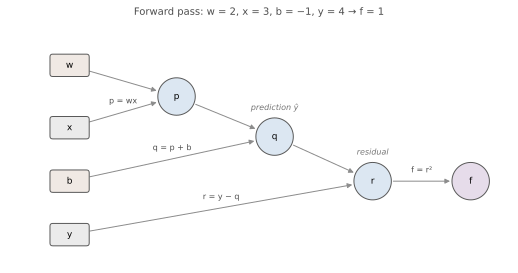

In [4]:
def scalar_forward_figure():
    """The scalar loss as a DAG, each edge labelled with what it computes."""
    fig, ax = new_graph_axes(figsize=(10.4, 3.9))
    draw_scalar_nodes(ax)

    P = SCALAR_POS
    draw_edge(ax, P['w'], P['p'])
    draw_edge(ax, P['x'], P['p'], label='p = wx')
    draw_edge(ax, P['p'], P['q'])
    draw_edge(ax, P['b'], P['q'], label='q = p + b')
    draw_edge(ax, P['q'], P['r'])
    draw_edge(ax, P['y'], P['r'], label='r = y − q')
    draw_edge(ax, P['r'], P['f'], label='f = r²')

    for node, note in (('q', 'prediction ŷ'), ('r', 'residual')):
        ax.text(P[node][0], P[node][1] + 0.56, note, ha='center', va='bottom',
                fontsize=8, color='0.45', style='italic')

    ax.set_xlim(-1.4, 9.9)
    ax.set_ylim(-1.1, 4.4)
    graph_title(ax, 'Forward pass:  w = 2, x = 3, b = −1, y = 4  →  f = 1')
    fig.tight_layout()

scalar_forward_figure()

### The chain rule

We want the gradients $\partial f/\partial w$ and $\partial f/\partial b$. Since $f$ is built by
composing simple operations, we use the **chain rule**: if $z$ depends on $y$, and $y$ depends
on $x$, then

$$\frac{dz}{dx} = \frac{dz}{dy}\,\frac{dy}{dx}.$$

Applied repeatedly, the derivative along a chain of operations is the product of the derivatives
of the individual steps. We call the derivative of a single operation with respect to one of its
inputs a **local derivative**. It depends only on that one operation (multiply, add, subtract,
square), so it is easy to write down.

In the graph, $w$ reaches $f$ along the path $w \to p \to q \to r \to f$. Multiplying the local
derivatives along this path, written in the same order as the path:

$$\frac{\partial f}{\partial w}
  = \frac{\partial p}{\partial w}\,\frac{\partial q}{\partial p}\,\frac{\partial r}{\partial q}\,\frac{\partial f}{\partial r}
  = (x)(1)(-1)(2r)
  = (3)(1)(-1)(-2) = 6.$$

Likewise, $b$ reaches $f$ along the path $b \to q \to r \to f$:

$$\frac{\partial f}{\partial b}
  = \frac{\partial q}{\partial b}\,\frac{\partial r}{\partial q}\,\frac{\partial f}{\partial r}
  = (1)(-1)(2r)
  = (1)(-1)(-2) = 2.$$

The two products **share their last two factors**, $\frac{\partial r}{\partial q}\frac{\partial f}{\partial r} = 2$,
which is $\partial f/\partial q$. In a network with millions of parameters, most parameters share long
stretches of their paths to the loss, so computing each product separately would repeat the same work
many times. Backpropagation avoids this by building the products up from the output, so each shared
factor is computed once.

### The backward pass, step by step

Writing the factors in path order shows how to organize the computation. Group the product for
$\partial f/\partial w$ starting from the end:

$$\frac{\partial f}{\partial w}
  = \frac{\partial p}{\partial w}\left(\frac{\partial q}{\partial p}\left(\frac{\partial r}{\partial q}\left(\frac{\partial f}{\partial r}\right)\right)\right).$$

Each parenthesized group is the product of the local derivatives from some node to the end of the
path, so by the chain rule it is the derivative of $f$ with respect to that node: the innermost
group is $\partial f/\partial r$, the next is $\partial f/\partial q$, then $\partial f/\partial p$, and the whole
product is $\partial f/\partial w$.

For every node $u$ we will use the following notation:

$$g_u = \frac{\partial f}{\partial u} = \text{the product of the local derivatives from } u \text{ to the output}.$$

In our example the derivatives can be summarized in the following table:

| node | $g_u$ |
|---|---|
| $r$ | $\frac{\partial f}{\partial r}$ |
| $q$ | $\frac{\partial r}{\partial q}\,\frac{\partial f}{\partial r} = \frac{\partial r}{\partial q}\, g_r$ |
| $p$ | $\frac{\partial q}{\partial p}\,\frac{\partial r}{\partial q}\,\frac{\partial f}{\partial r} = \frac{\partial q}{\partial p}\, g_q$ |
| $w$ | $\frac{\partial p}{\partial w}\,\frac{\partial q}{\partial p}\,\frac{\partial r}{\partial q}\,\frac{\partial f}{\partial r} = \frac{\partial p}{\partial w}\, g_p$ |

The table expresses a more general statement, that if $u$ has a single outgoing edge into node $v$ then

$$g_u = \frac{\partial v}{\partial u}\; g_v.$$

In words: **a node's gradient is the local derivative of its outgoing edge times the gradient of the
node it feeds into.** $g_v$ is often called the *upstream* gradient, because it arrives from the
direction of the output. 

This observation leads to an algorithm for computing derivaties:
We start at the output with $g_f = \partial f/\partial f = 1$ and work backward
one edge at a time. Each $g_u$ is computed once and reused by every path through $u$; for example,
$g_q$ serves both $w$ and $b$. Every node in our example has a single outgoing edge, so this rule
is all we need; nodes with several outgoing edges are covered below.

**The backwards pass node by node.** Let's walk through the calculation of the derivaties with respect to $w$ and $b$ in our example.

1. **Start at the output:** $g_f = \dfrac{\partial f}{\partial f} = 1$.

2. **Edge $f \leftarrow r$** (operation $f = r^2$, local derivative $\partial f/\partial r = 2r = -2$):
   $$g_r = 2r \cdot g_f = (-2) \cdot 1 = -2.$$

3. **Edge $r \leftarrow q$** (operation $r = y - q$, local derivative $\partial r/\partial q = -1$):
   $$g_q = (-1) \cdot g_r = (-1) \cdot (-2) = 2.$$

4. **Edges $q \leftarrow p$ and $q \leftarrow b$** (operation $q = p + b$; local derivatives $\partial q/\partial p = 1$, $\partial q/\partial b = 1$):
   $$g_p = 1 \cdot g_q = 2, \qquad \boxed{g_b = 1 \cdot g_q = 2}.$$
   Now we can read the gradient for the bias: $\partial f/\partial b = 2$.

5. **Edge $p \leftarrow w$** (operation $p = w x$, local derivative $\partial p/\partial w = x = 3$):
   $$\boxed{g_w = x \cdot g_p = 3 \cdot 2 = 6}.$$

So the parameter gradients are $\partial f/\partial w = 6$ and $\partial f/\partial b = 2$, in agreement with the values the chain rule gave us. Notice that $g_q = 2$, the shared factor from the
chain-rule section, was computed **once** and then reused for *both* the bias $b$ and the path through
$p$ to $w$: reusing shared upstream gradients is exactly what makes backprop efficient. The diagram below shows the local derivative on each edge (blue) and the
gradient that ends up at each node (red).

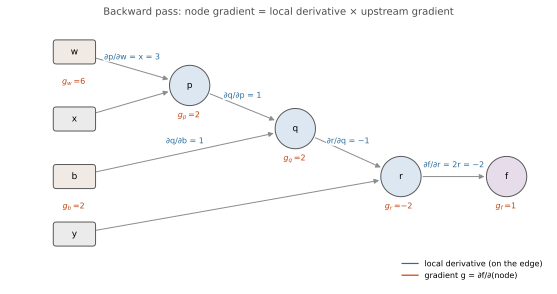

In [21]:
def scalar_backward_figure():
    """The same graph, annotated with local derivatives and the gradients."""
    fig, ax = new_graph_axes(figsize=(10.4, 4.2))
    draw_scalar_nodes(ax)

    P = SCALAR_POS
    # Forward edges labelled with the LOCAL derivative.  Only edges on a
    # parameter path are labelled; we never propagate into the data x and y.
    local = [('w', 'p', '∂p/∂w = x = 3'), ('x', 'p', None),
             ('p', 'q', '∂q/∂p = 1'), ('b', 'q', '∂q/∂b = 1'),
             ('q', 'r', '∂r/∂q = −1'), ('y', 'r', None),
             ('r', 'f', '∂f/∂r = 2r = −2')]
    for src, dst, label in local:
        draw_edge(ax, P[src], P[dst], label=label, label_color=BLUE)

    # the gradient that accumulates at each node, just below it
    grads = {'f': '$g_f = 1$', 'r': '$g_r = -2$', 'q': '$g_q = 2$',
             'p': '$g_p = 2$', 'w': '$g_w = 6$', 'b': '$g_b = 2$'}
    for n, label in grads.items():
        ax.text(P[n][0], P[n][1] - 0.54, label, ha='center', va='top',
                fontsize=8, color=RED, zorder=5)

    ax.plot([], [], color=BLUE, linewidth=1.2,
            label='local derivative (on the edge)')
    ax.plot([], [], color=RED, linewidth=1.2,
            label='gradient  g = ∂f/∂(node)')
    ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=8,
              frameon=False)

    ax.set_xlim(-1.4, 9.9)
    ax.set_ylim(-1.5, 4.05)
    graph_title(ax, 'Backward pass:  node gradient = local derivative '
                    '× upstream gradient')
    fig.tight_layout()

scalar_backward_figure()

Let's verify that PyTorch autograd produces the same result:

In [6]:
import torch
# data and parameters
x, y = 3.0, 4.0      # a single data point
w, b = 2.0, -1.0     # the parameters

# verify against autograd
wt = torch.tensor(w, requires_grad=True)
bt = torch.tensor(b, requires_grad=True)

f_t = (y - (wt * x + bt)) ** 2
f_t.backward()   # traverses the graph in reverse, filling wt.grad and bt.grad

print(f"autograd: df/dw = {wt.grad.item()},   df/db = {bt.grad.item()}")

autograd: df/dw = 6.0,   df/db = 2.0


### Nodes with multiple outgoing edges

So far every node feeds into exactly one operation. In general, a node can be connected to multiple other nodes. To see what happens, let's add an $\ell_2$ penalty on the weight to our loss:

$$t = \tfrac{\lambda}{2} w^2, \qquad f = r^2 + t.$$

Now $w$ has **two outgoing edges**: one into $p = wx$, as before, and one into $t$. A small change in
$w$ changes $f$ along both edges, and the two effects add. This is the **multivariate chain rule**.
It is usually stated as follows: if $z$ depends on $y_1, \dots, y_n$, each of which depends on $x$, then

$$\frac{\partial z}{\partial x} = \sum_{i=1}^{n} \frac{\partial y_i}{\partial x}\,\frac{\partial z}{\partial y_i}.$$

In our graph notation the rule becomes:

$$g_u = \sum_{\text{edges } u \to v} \frac{\partial v}{\partial u}\; g_v.$$

With a single outgoing edge this sum has one term, which is the rule we used above.
Because backprop processes nodes from the output backward, the upstream gradients $g_v$ of all the
nodes that $u$ feeds into are known by the time it reaches $u$.

For our example $g_t = \partial f/\partial t = 1$, so

$$g_w = \frac{\partial p}{\partial w}\, g_p + \frac{\partial t}{\partial w}\, g_t = x \cdot g_p + \lambda w \cdot g_t.$$

Nodes with multiple outgoing edges are everywhere in an MLP: every hidden unit feeds into every
output unit, and with weight decay each weight matrix feeds into both its layer and the regularizer
$s$ (see the computational graph of the MLP above).

In [7]:
# In PyTorch:
lam_w = 0.5

wt = torch.tensor(w, requires_grad=True)
f_t = (y - (wt * x + b)) ** 2 + (lam_w / 2) * wt ** 2
f_t.backward()
print(f"autograd: df/dw = {wt.grad.item()}")

autograd: df/dw = 7.0


## Backpropagation

How do we calculate the gradient of a multi-layer neural network?
In the case of our simple network, this is the function

$$
f(\mathbf{x}) = \mathbf{W}^{(2)} \sigma(\mathbf{W}^{(1)} \mathbf{x}).
$$

This entails calculating derivatives with respect to $\mathbf{W}^{(1)}$ and
$\mathbf{W}^{(2)}$. The derivative with respect to $\mathbf{W}^{(2)}$ is
straightforward, but the derivative with respect to $\mathbf{W}^{(1)}$ requires the
chain rule.

In the scalar example we saw that backpropagation is the chain rule applied at every
node, evaluated from the output back to the input. 
The same holds for the MLP; the only difference is that the nodes now hold vectors and matrices.

### Backprop for the MLP in matrix form

Let's derive the gradients for our two layer network. To keep
the algebra readable we do this for a single training example and squared-error loss.
Our objective is $J = L + s$ with

$$L = \lVert \mathbf{o} - \mathbf{y}\rVert^2, \qquad
  s = \tfrac{\lambda}{2}\left(\lVert\mathbf{W}^{(1)}\rVert_F^2 + \lVert\mathbf{W}^{(2)}\rVert_F^2\right).$$

Recall the forward pass:

$$\mathbf{z} = \mathbf{W}^{(1)}\mathbf{x}, \qquad
  \mathbf{h} = \sigma(\mathbf{z}), \qquad
  \mathbf{o} = \mathbf{W}^{(2)}\mathbf{h}, \qquad
  J = L(\mathbf{o},\mathbf{y}) + s.$$

Time for the backward pass. 

We define $\boldsymbol{\delta}$ as the gradient of $J$ with respect to
each intermediate ("the upstream gradient").  We now compute those gradients:

**The output.** Since $L = \lVert\mathbf{o}-\mathbf{y}\rVert^2$,

$$\boldsymbol{\delta}_o = \frac{\partial J}{\partial \mathbf{o}} = 2(\mathbf{o} - \mathbf{y}). $$

**The second weight matrix.** $\mathbf{W}^{(2)}$ feeds into $\mathbf{o} = \mathbf{W}^{(2)}\mathbf{h}$
and into the regularizer $s$. Summing the two contributions,

$$\frac{\partial J}{\partial \mathbf{W}^{(2)}}
   = \boldsymbol{\delta}_o\,\mathbf{h}^\top + \lambda\,\mathbf{W}^{(2)}.$$

**The hidden layer.** Propagating through $\mathbf{o}=\mathbf{W}^{(2)}\mathbf{h}$,

$$\boldsymbol{\delta}_h \;=\; \frac{\partial J}{\partial \mathbf{h}} = \big(\mathbf{W}^{(2)}\big)^\top \boldsymbol{\delta}_o.$$

Explanation.  Each hidden unit $h_j$ has an outgoing edge to every output
$o_k$, with local derivative $\partial o_k/\partial h_j = W^{(2)}_{kj}$. Summing over these edges gives
$\partial J/\partial h_j = \sum_k W^{(2)}_{kj}\,\delta_{o,k}$, which is the $j$-th entry of
$\big(\mathbf{W}^{(2)}\big)^\top \boldsymbol{\delta}_o$. **Multiplying by the transpose is the sum over those outgoing edges.**

**The activation.** With $\mathbf{h} = \sigma(\mathbf{z})$, the gradient is scaled
elementwise by $\sigma'(\mathbf{z})$ (for ReLU, $\sigma'(z)=\mathbf{1}[z>0]$):

$$\boldsymbol{\delta}_z \;=\; \frac{\partial J}{\partial \mathbf{z}}
   = \boldsymbol{\delta}_h \odot \sigma'(\mathbf{z}).$$

**The first weight matrix.** Finally, since $\mathbf{z} = \mathbf{W}^{(1)}\mathbf{x}$, and $\mathbf{W}^{(1)}$
also has an outgoing edge into the regularizer,

$$\frac{\partial J}{\partial \mathbf{W}^{(1)}}
   = \boldsymbol{\delta}_z\,\mathbf{x}^\top + \lambda\,\mathbf{W}^{(1)}.$$

Notice the pattern: each weight-matrix gradient is an **outer product** of the upstream
gradient at that layer's output with the input that fed into it, and the upstream gradient
is passed further back by multiplying with $\big(\mathbf{W}\big)^\top$. That regular
structure is exactly what makes backprop straitforward to implement as a loop over layers.

### Where the outer product comes from

Matrix derivatives can look like magic, so let's derive $\partial L/\partial \mathbf{W}^{(2)}$ using only the scalar chain rule (the regularizer just adds $\lambda W^{(2)}_{kj}$ to each entry).

The weight $W^{(2)}_{kj}$ connects hidden unit $j$ to output $k$, and it appears in only one output:

$$o_k = \sum_{j'} W^{(2)}_{kj'}\, h_{j'}.$$

So $W^{(2)}_{kj}$ has a single outgoing edge, into $o_k$, with local derivative
$\partial o_k/\partial W^{(2)}_{kj} = h_j$. The upstream gradient at $o_k$ is $\delta_{o,k} = 2(o_k - y_k)$,
and the chain rule gives

$$\frac{\partial L}{\partial W^{(2)}_{kj}} = \delta_{o,k}\, h_j.$$

Collecting these numbers into a matrix with the same layout as $\mathbf{W}^{(2)}$ (row $k$, column $j$):

$$\frac{\partial L}{\partial \mathbf{W}^{(2)}} =
\begin{pmatrix}
\delta_{o,1} h_1 & \delta_{o,1} h_2 & \cdots \\
\delta_{o,2} h_1 & \delta_{o,2} h_2 & \cdots \\
\vdots & \vdots & \ddots
\end{pmatrix}
= \boldsymbol{\delta}_o\, \mathbf{h}^\top,$$

which is the outer product in the formula above.

**A shape check.** There is one partial derivative per weight, so $\partial L/\partial \mathbf{W}$ always has the
same shape as $\mathbf{W}$. Here $\mathbf{W}^{(2)}$ is $q \times h$, $\boldsymbol{\delta}_o$ has length $q$ and
$\mathbf{h}$ has length $h$; the only way to combine the two vectors into a $q \times h$ matrix is
$\boldsymbol{\delta}_o \mathbf{h}^\top$. The same check works for the other formulas: $\boldsymbol{\delta}_z \mathbf{x}^\top$
is $h \times d$, like $\mathbf{W}^{(1)}$, and $\partial J/\partial\mathbf{h}$ has length $h$, which requires multiplying
$\boldsymbol{\delta}_o$ (length $q$) by the $h \times q$ matrix $\big(\mathbf{W}^{(2)}\big)^\top$. Checking shapes is a
quick way to remember or verify these formulas.

### Minibatches

The derivation above was for a single example. In practice we process a minibatch, stored as in
previous notebooks with one example per row: $\mathbf{X} \in \mathbb{R}^{n \times d}$. The forward pass of the
first layer is then $\mathbf{Z} = \mathbf{X}\big(\mathbf{W}^{(1)}\big)^\top$, whose row $i$ is $\big(\mathbf{W}^{(1)}\mathbf{x}^{(i)}\big)^\top$,
the result for example $i$.

The loss is the average of the per-example losses, so its gradient is the average of the
per-example gradients. For $\mathbf{W}^{(1)}$ this is an average of outer products,
$\frac1n\sum_i \boldsymbol{\delta}_z^{(i)} \mathbf{x}^{(i)\top}$. Stacking the upstream gradients as rows of a matrix
$\boldsymbol{\Delta}_z \in \mathbb{R}^{n \times h}$, the same way the examples are stacked in $\mathbf{X}$, this sum is a
single matrix product:

$$\frac{\partial J}{\partial \mathbf{W}^{(1)}} = \frac1n\,\boldsymbol{\Delta}_z^\top \mathbf{X} + \lambda\,\mathbf{W}^{(1)}.$$

Checking the shapes: $\boldsymbol{\Delta}_z^\top$ is $h \times n$ and $\mathbf{X}$ is $n \times d$, giving $h \times d$, the
shape of $\mathbf{W}^{(1)}$. This shows how backprop on a minibatch runs as a few large matrix
multiplications, which GPUs do very efficiently.

## Implementing backprop from scratch

Now let's put the derivation to work: we'll implement the forward and backward passes of
the two-layer MLP **by hand**, then confirm the hand-computed gradients agree with
PyTorch's autograd to machine precision.

In [8]:
import torch

torch.manual_seed(0)

# dimensions and a single training example
d, h_dim, q = 4, 5, 3       # input / hidden / output sizes
lam = 0.1                    # L2 regularization strength

x = torch.randn(d)
y = torch.randn(q)

# parameters (require grad so we can cross-check with autograd)
W1 = torch.randn(h_dim, d, requires_grad=True)
W2 = torch.randn(q, h_dim, requires_grad=True)

print("shapes:  x", tuple(x.shape), " W1", tuple(W1.shape),
      " W2", tuple(W2.shape), " y", tuple(y.shape))

shapes:  x (4,)  W1 (5, 4)  W2 (3, 5)  y (3,)


### Forward pass

We compute and **store** each intermediate (`z`, `h`, `o`), because the backward pass
needs them.

In [9]:
# forward pass, storing intermediates
z = W1 @ x                      # hidden pre-activation
h = torch.relu(z)               # hidden activation
o = W2 @ h                      # output
L = torch.sum((o - y)**2)                             # squared-error loss
s = (lam / 2) * (torch.sum(W1**2) + torch.sum(W2**2)) # L2 regularizer
J = L + s                                             # objective

print(f"loss L = {L.item():.4f},  reg s = {s.item():.4f},  objective J = {J.item():.4f}")

loss L = 70.1739,  reg s = 1.6823,  objective J = 71.8561


### Backward pass, by hand

We now apply the matrix formulas derived above, top to bottom, propagating the upstream
gradient from the objective back to $\mathbf{W}^{(1)}$.

In [10]:
# backward pass implemented from scratch (no autograd)
with torch.no_grad():
    delta_o = 2 * (o - y)                    # dJ/do
    grad_W2 = torch.outer(delta_o, h) + lam * W2   # dJ/dW2  (outer product + reg)

    delta_h = W2.t() @ delta_o               # dJ/dh
    delta_z = delta_h * (z > 0).float()           # dJ/dz  (ReLU derivative gates the gradient)
    grad_W1 = torch.outer(delta_z, x) + lam * W1   # dJ/dW1  (outer product + reg)

print("hand-computed grad_W1 shape:", tuple(grad_W1.shape))
print("hand-computed grad_W2 shape:", tuple(grad_W2.shape))

hand-computed grad_W1 shape: (5, 4)
hand-computed grad_W2 shape: (3, 5)


### Checking against the autograd result

If our derivation is right, `J.backward()` should produce the same gradients.

In [11]:
J.backward()   # autograd traverses the graph in reverse and fills W1.grad, W2.grad

err_W1 = (grad_W1 - W1.grad).abs().max().item()
err_W2 = (grad_W2 - W2.grad).abs().max().item()
print(f"max |grad_W1 - autograd| = {err_W1:.2e}")
print(f"max |grad_W2 - autograd| = {err_W2:.2e}")
assert err_W1 < 1e-5 and err_W2 < 1e-5
print("[OK] hand-written backprop matches autograd")

max |grad_W1 - autograd| = 0.00e+00
max |grad_W2 - autograd| = 0.00e+00
[OK] hand-written backprop matches autograd


### Visualizing the backward flow

The diagram below shows the same network as a computational graph. Grey arrows are the
forward pass (left to right): the inputs and weights combine into $\mathbf{z}$, $\mathbf{h}$, $\mathbf{o}$, the loss
$L$, the regularizer $s$, and finally the objective $J = L + s$. Red dashed arrows are the
backward pass (right to left): starting from $J$, the gradient flows back along the chain. The
upstream gradient that arrives at each node is written below it: $\boldsymbol{\delta}_o$, $\boldsymbol{\delta}_h$ and $\boldsymbol{\delta}_z$.
The gradients for the weight matrices are shown in red at the top.

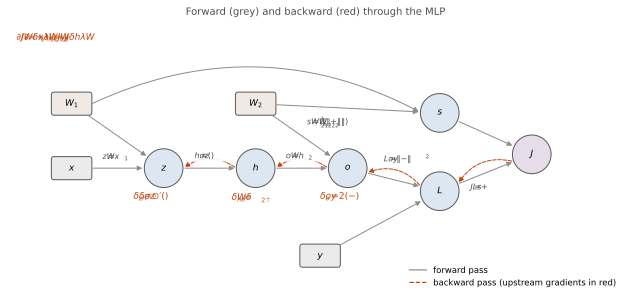

In [12]:
def mlp_graph_figure():
    """The MLP's graph with the forward pass and the backward pass overlaid."""
    fig, ax = new_graph_axes(figsize=(11.6, 4.3))

    pos = {'x':  (0.0, 1.4), 'W1': (0.0, 2.8),
           'z':  (2.0, 1.4), 'h':  (4.0, 1.4), 'W2': (4.0, 2.8),
           'o':  (6.0, 1.4), 'y':  (5.4, -0.5),
           'L':  (8.0, 0.9), 's':  (8.0, 2.6),
           'J':  (10.0, 1.7)}
    styles = {'x': ('box', DATA), 'y': ('box', DATA),
              'W1': ('box', PARAM), 'W2': ('box', PARAM),
              'z': ('circle', OP), 'h': ('circle', OP), 'o': ('circle', OP),
              'L': ('circle', OP), 's': ('circle', OP), 'J': ('circle', OBJ)}
    labels = {'x': '$x$', 'y': '$y$', 'W1': '$W_1$', 'W2': '$W_2$', 'z': '$z$',
              'h': '$h$', 'o': '$o$', 'L': '$L$', 's': '$s$', 'J': '$J$'}
    for n, (shape, color) in styles.items():
        draw_node(ax, pos[n], labels[n], shape, color)

    # ---- forward pass ----
    draw_edge(ax, pos['W1'], pos['z'])
    draw_edge(ax, pos['x'],  pos['z'], label=r'$z = W_1 x$')
    draw_edge(ax, pos['z'],  pos['h'], label=r'$h = \sigma(z)$')
    draw_edge(ax, pos['W2'], pos['o'])
    draw_edge(ax, pos['h'],  pos['o'], label=r'$o = W_2 h$')
    draw_edge(ax, pos['o'],  pos['L'],
              label=r'$L = \|o - y\|^2$',
              label_off=0.34, label_dx=0.28)
    draw_edge(ax, pos['y'],  pos['L'])
    draw_edge(ax, pos['W1'], pos['s'], curve=-0.25)        # curved to clear W2
    draw_edge(ax, pos['W2'], pos['s'],
              label=r'$s = \frac{\lambda}{2}(\|W_1\|^2 + \|W_2\|^2)$',
              label_off=-0.42)
    draw_edge(ax, pos['L'],  pos['J'], label=r'$J = L + s$', label_off=-0.40)
    draw_edge(ax, pos['s'],  pos['J'])

    # ---- backward pass, curving back along the main chain ----
    for src, dst in [('J', 'L'), ('L', 'o'), ('o', 'h'), ('h', 'z')]:
        draw_edge(ax, pos[src], pos[dst], color=RED, curve=0.35, dashed=True)

    # the upstream gradient that arrives at each node, written just below it
    # (σ′ is the unicode prime: mathtext's ' is drawn from a font browsers lack)
    deltas = {'o': r'$\delta_o = 2(o - y)$',
              'h': r'$\delta_h = W_2^\top \delta_o$',
              'z': r'$\delta_z = \delta_h \odot \sigma′(z)$'}
    for n, label in deltas.items():
        ax.text(pos[n][0], pos[n][1] - 0.52, label, ha='center', va='top',
                fontsize=9, color=RED, zorder=5)

    # ---- what the backward pass leaves at each weight matrix ----
    ax.text(-1.2, 4.25, r'$\partial J/\partial W_1 = \delta_z x^\top + \lambda W_1$'
            r'$\qquad\partial J/\partial W_2 = \delta_o h^\top + \lambda W_2$',
            color=RED, fontsize=9, ha='left', va='center')

    ax.plot([], [], color=GRAY, linewidth=1.2, label='forward pass')
    ax.plot([], [], color=RED, linewidth=1.2, linestyle='--',
            label='backward pass (upstream gradients in red)')
    ax.legend(loc='lower right', fontsize=8.5, frameon=False)

    ax.set_xlim(-1.4, 12.0)
    ax.set_ylim(-1.35, 4.6)
    graph_title(ax, 'Forward (grey) and backward (red) through the MLP')
    fig.tight_layout()

mlp_graph_figure()

## Training needs more memory than prediction

Notice that the backward pass reused `z`, `h`, and `o` which are the intermediates from the
forward pass. This is the key coupling between the two passes: **the values computed going
forward must be kept in memory until the backward pass consumes them.**

At prediction time we only run the forward pass and can discard each intermediate as soon
as the next layer is computed. During training we cannot: the gradient formulas need
$\mathbf{h}$ (for $\partial J/\partial \mathbf{W}^{(2)}$), $\mathbf{z}$ (for the activation
derivative), and $\mathbf{x}$ (for $\partial J/\partial \mathbf{W}^{(1)}$). This is why
training a network of a given size requires substantially more memory than running it for
inference, and why very deep networks sometimes trade compute for memory via techniques
like *gradient checkpointing* (recomputing intermediates in the backward pass instead of
storing them).

## What backprop tells us about training deep networks

Our network has a single hidden layer. With more layers, the backward pass repeats the same two
steps at every layer: multiply by the transpose of the layer's weight matrix, then multiply
elementwise by the derivative of the activation. Writing the elementwise product as multiplication
by the diagonal matrix $\mathbf{D}^{(l)} = \operatorname{diag}\big(\sigma'(\mathbf{z}^{(l)})\big)$, the upstream gradient at the
first hidden layer of a network with $L$ layers is

$$\boldsymbol{\delta}_z^{(1)} = \mathbf{D}^{(1)} \big(\mathbf{W}^{(2)}\big)^\top \mathbf{D}^{(2)} \big(\mathbf{W}^{(3)}\big)^\top \cdots\, \mathbf{D}^{(L-1)} \big(\mathbf{W}^{(L)}\big)^\top \boldsymbol{\delta}_o.$$

For our network ($L = 2$) this is $\boldsymbol{\delta}_z = \mathbf{D}^{(1)}\big(\mathbf{W}^{(2)}\big)^\top\boldsymbol{\delta}_o$, the formula derived above.

So the gradient that reaches the early layers is a **product of many matrices**. If each factor
$\mathbf{D}^{(l)}\big(\mathbf{W}^{(l+1)}\big)^\top$ scales the gradient by a typical factor $c$, then after $k$ layers the
gradient is scaled by roughly $c^k$.
This explains the two common failure modes of training deep networks:

* **Vanishing gradients:** if $c < 1$, the early layers receive gradients so small that they barely learn.
  The sigmoid activation is a common culprit: its derivative is at most $1/4$, so it shrinks the
  gradient by a factor of at least 4 at every layer.
* **Exploding gradients:** if $c > 1$, the gradients grow from layer to layer until the updates are
  huge and training diverges.

The ReLU derivative is 1 for active units, so it does not shrink the gradient there; for inactive
units it is 0, so a dead unit passes no gradient at all, as we saw in the XOR notebook. We will see
remedies for vanishing and exploding gradients (careful initialization, normalization layers, residual
connections) later in the course.

The code below simulates the backward calculation with random weights and random pre-activations, and tracks the size of the upstream gradient as it travels back through the layers, for the sigmoid and for ReLU activation functions.

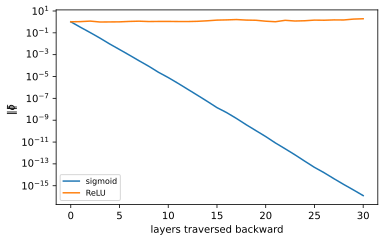

In [13]:
def backward_norms(act_deriv, depth=30, width=100, seed=0):
    # size of the upstream gradient after each step of  delta <- sigma'(z) * (W^T delta),
    # with random weights and random pre-activations z
    torch.manual_seed(seed)
    delta = torch.randn(width) / width**0.5
    norms = [delta.norm().item()]
    for _ in range(depth):
        # random weights, scaled the way ReLU networks are usually initialized (more on this later)
        W = torch.randn(width, width) * (2 / width)**0.5
        z = torch.randn(width)
        delta = act_deriv(z) * (W.t() @ delta)
        norms.append(delta.norm().item())
    return norms

sigmoid_deriv = lambda z: torch.sigmoid(z) * (1 - torch.sigmoid(z))
relu_deriv = lambda z: (z > 0).float()

plt.figure(figsize=(5.5, 3.5))
plt.semilogy(backward_norms(sigmoid_deriv), label='sigmoid')
plt.semilogy(backward_norms(relu_deriv), label='ReLU')
plt.xlabel('layers traversed backward')
plt.ylabel(r'$\|\delta\|$')
plt.legend(fontsize=8)
plt.tight_layout();

This plot demonstrates that sigmoid gradients decay exponentially as they travel toward earlier layers, while ReLU gradients remain comparatively stable.

The difference comes from the activation derivative. The sigmoid's derivative is at most $1/4$, so every layer shrinks the gradient. The ReLU derivative is 1 for active units, so the gradient passes through them unchanged.

## Local minima

The loss of linear regression and logistic regression is convex, so gradient descent finds the global
minimum. The loss of an MLP is not convex: it can have many local minima and flat regions, and
gradient-based training is not guaranteed to find the global minimum.

Is this a problem? Less than it sounds: In practice large networks trained with SGD usually reach good solutions.
There are other issues that we will discuss in the next notebook!

The backpropagation algorithm was proposed independently several times:

* Rumelhart, D. E.; Hinton, G. E.; Williams, R. J. (1986). "Learning representations by back-propagating errors." *Nature* 323 (6088): 533-536.
* Werbos, P. J. (1974). *Beyond Regression: New Tools for Prediction and Analysis in the Behavioral Sciences.* PhD thesis, Harvard University.

## Summary

* **Forward propagation** computes and stores the network's output and every intermediate
  variable, moving from input to output through the computational graph.
* A **computational graph** expresses the model as elementary operations; its structure is
  what lets us apply the chain rule.
* **Backpropagation** computes gradients by traversing that graph **in reverse**. At each layer
  the gradient is an outer product of the upstream gradient with the layer's input,
  and the upstream gradient is passed further back by multiplying with $\mathbf{W}^\top$ and
  gating through the activation's derivative.
* The **multivariate chain rule**: summing gradient contributions over all paths is the
  mathematical heart of the algorithm.
* Because the gradient at an early layer is a **product of many matrices**, it can shrink or grow
  exponentially with depth: the **vanishing** and **exploding gradient** problems.
* Forward and backward passes are **interdependent**: the backward pass consumes the stored
  forward intermediates, so training needs more memory than prediction.